# Chapter 12: Grover Algorithm

Grover's algorithm is the quintessential quantum search: given a Boolean condition that
"marks" one (or a few) states out of $N=2^n$ possibilities, it finds a marked state in
$O(\sqrt{N})$ queries — a quadratic speed-up over the $O(N)$ classical exhaustive search, and
provably optimal for unstructured search. This notebook builds the algorithm from its two
elementary ingredients, **phase kickback** and the **phase oracle**, combines them into the
**Grover operator** (oracle $U$ followed by the reflection $R_\psi = 2|\psi\rangle\langle\psi| - I$),
and applies it to two engineering problems: truss feasibility and microstructure void detection.

Each Grover iteration rotates the state by $2\theta$ toward the marked solution $|s\rangle$, so
after $K\approx \tfrac{\pi}{4}\sqrt{N}$ iterations we measure $s$ with near-certainty. Along the
way we examine over/under-rotation (the success probability $P(K)=\sin^2((2K{+}1)\theta)$ is
periodic), the rapidly growing oracle gate cost, and coordinate encoding — a key idea that shrinks
the void-search register from one qubit per cell to $2m=\log_2 N$ address qubits.

---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions

In [1]:
# Setup and imports
import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit,transpile
from IPython.display import display
from qiskit import ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import grover_operator

from Chapter08_QuantumGates_functions import (simulate_measurements, estimateCircuitGates)



## Phase kickback: barebones  *(Book §12.1, Example 12.1)*

Recall the CNOT gate leaves the control unchanged and flips the target when the control is
$|1\rangle$. A curious thing happens when the *target* qubit is in $|-\rangle$: the phase of the
**control** flips. Here we bring the ancilla q0 to $|-\rangle$ (via $X$ then $H$), apply CNOT, and
then undo the operations on q0 — the target returns unchanged while the control has taken a phase
kickback.

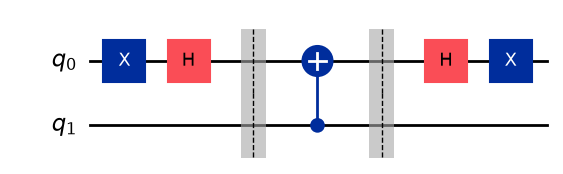

In [2]:
circuit = QuantumCircuit(2)  
circuit.x(0)
circuit.h(0)
circuit.barrier()
circuit.cx(1,0)
circuit.barrier()
circuit.h(0)
circuit.x(0)
display(circuit.draw('mpl'))

## Phase kickback: worked example  *(Book §12.1, Example 12.1)*

Now we prepare the control q1 in a general state $\tfrac{\sqrt3}{2}|0\rangle+\tfrac12|1\rangle$ via
$R_Y(\pi/3)$. After CNOT (target q0 in $|-\rangle$) the term $|1-\rangle$ picks up a minus sign, so
the control transforms to $\tfrac{\sqrt3}{2}|0\rangle-\tfrac12|1\rangle$. In general
$\alpha|0\rangle+\beta|1\rangle \to \alpha|0\rangle-\beta|1\rangle$: phase kickback is the
fundamental building block of Grover's algorithm.

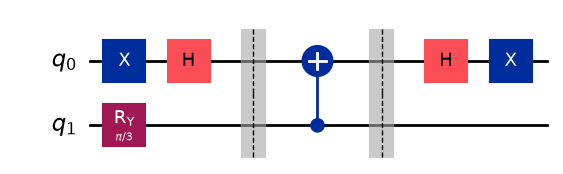

<IPython.core.display.Latex object>

In [3]:
circuit = QuantumCircuit(2)  
circuit.x(0)
circuit.h(0)
circuit.ry(theta = np.pi/3, qubit=1) 
circuit.barrier()
circuit.cx(1,0)
circuit.barrier()
circuit.h(0)
circuit.x(0)
display(circuit.draw('mpl'))
psi = Statevector(circuit)
display(psi.draw('latex'))

## Phase oracle: barebones  *(Book §12.2, Example 12.2)*

A phase oracle generalizes kickback to multi-qubit states, acting as a **marking device**. The
ancilla q0 is initialized to $|-\rangle$ and a multi-controlled `mcx([1,2,3], 0, ctrl_state='101')`
flips q0 when, and only when, the control register (q3,q2,q1) is in state $|101\rangle$. That
marked state alone picks up a phase $-1$; all others are untouched.

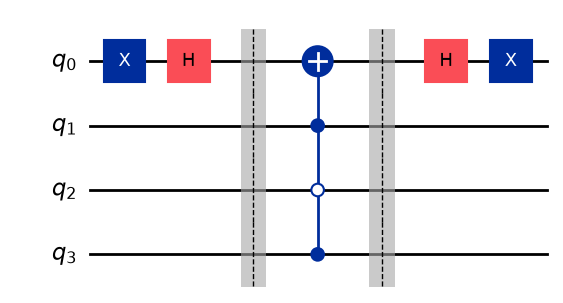

<IPython.core.display.Latex object>

In [4]:
# 4 Qubits: q0 is Ancilla, q1-q3 are Input
circuit = QuantumCircuit(4)

# 1. Prepare Ancilla (q0) in the |-> state
circuit.x(0)
circuit.h(0)
circuit.barrier()

# 2. Phase Oracle for |101> 
# Input register is (q3, q2, q1). For |101>, q2 must be flipped.
circuit.mcx([1, 2, 3], 0, ctrl_state = '101')   # Controls: q1,q2,q3. Target: q0
circuit.barrier()

# 3. Clean up Ancilla to return it to |0>
circuit.h(0)
circuit.x(0)

display(circuit.draw('mpl'))

# Verify the result
# The statevector will show a negative sign on the |1010> state 
# (where the last 0 is the ancilla q0)
psi = Statevector(circuit)
display(psi.draw('latex'))

## Phase oracle: uniform superposition  *(Book §12.2, Example 12.2)*

Same oracle, but now the control qubits q1-q3 are first put into a uniform superposition with
Hadamards. The output is $\tfrac{1}{\sqrt8}\big(|000\rangle+\cdots+|111\rangle\big)$ with the
phase of $|101\rangle$ alone flipped to $-1$ — the oracle has marked that state within the
superposition.

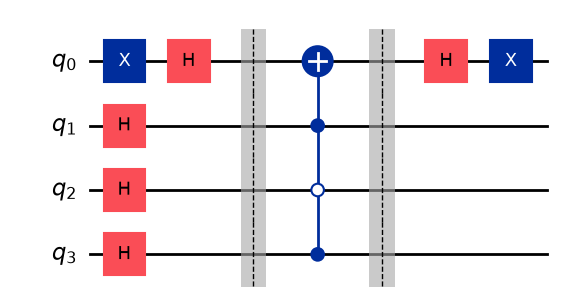

<IPython.core.display.Latex object>

In [5]:
# 4 Qubits: q0 is Ancilla, q1-q3 are Input
circuit = QuantumCircuit(4)

# 1. Prepare Ancilla (q0) in the |-> state
circuit.x(0)
circuit.h(0)

for qubit in [1, 2, 3]:
    circuit.h(qubit)
circuit.barrier()
# 2. Phase Oracle for |101> 
# Input register is (q3, q2, q1). For |101>, q2 must be flipped.
circuit.mcx([1, 2, 3], 0, ctrl_state = '101')   # Controls: q1,q2,q3. Target: q0
circuit.barrier()

# 3. Clean up Ancilla to return it to |0>
circuit.h(0)
circuit.x(0)
display(circuit.draw('mpl'))

# Verify the result
# The statevector will show a negative sign on the |1010> state 
# (where the last 0 is the ancilla q0)
psi = Statevector(circuit)
display(psi.draw('latex'))

## Qiskit's built-in `PhaseOracleGate`  *(Book §12.3, Example 12.3)*

Phase oracles are so central that Qiskit provides `PhaseOracleGate`, which builds one directly from
a Boolean expression — no need to prepare an ancilla by hand, it is handled internally. The Boolean
expression `x2 & ~x1 & ~x0` corresponds to $|100\rangle$; `get_qiskit_expression` converts it to the
required form (passing the qubit count, since not all variables need appear). Applied to the uniform
superposition, the phase of $|100\rangle$ is flipped.

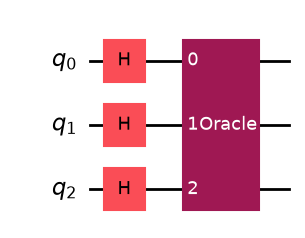

<IPython.core.display.Latex object>

In [6]:
from qiskit.circuit.library import PhaseOracleGate
from Chapter12_GroverAlgorithm_functions import get_qiskit_expression

expression = 'x2 & ~x1 & ~x0' # state 100
qiskit_expr = get_qiskit_expression(expression, 3)

oracle_gate = PhaseOracleGate(qiskit_expr,label='Oracle')

# Now just add it to your main circuit
n = 3 # Don't include ancilla
circuit = QuantumCircuit(n)
for qubit in range(n):
    circuit.h(qubit)
circuit.append(oracle_gate, range(n))
display(circuit.draw('mpl'))
psi = Statevector(circuit)
display(psi.draw('latex'))

### Transpiled oracle for $|100\rangle$  *(Book §12.3, Figure 12.4)*

Transpiling the single-oracle circuit to `{u3, cx}` exposes the underlying basis gates.
`estimateCircuitGates` reports 12 single-qubit gates, 6 CX gates, and depth 12 for this 3-qubit
oracle — modest, but the CX count will grow much faster than linearly as the oracle grows.

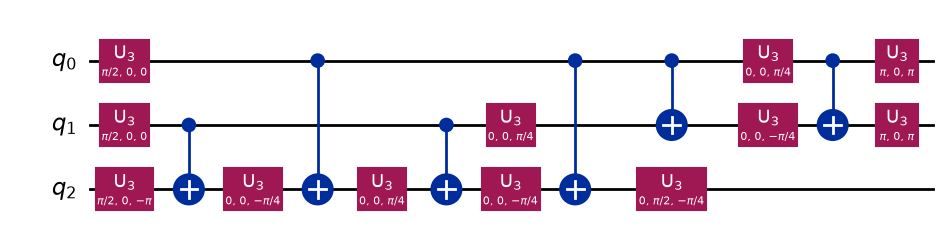

--- Circuit Analysis ---
Qubits: 3
Single-qubit gates: 12
CX/ECR gates: 6
Total gates: 18
Depth: 12
{'num_qubits': 3, 'single_gate_count': 12, 'cx_gates': 6, 'total_gates': 18, 'depth': 12, 'transpiled_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000246FAF69A90>}


In [7]:
from Chapter08_QuantumGates_functions import  estimateCircuitGates

transpiled_circuit = transpile(circuit, basis_gates=['u3', 'cx'])
display(transpiled_circuit.draw('mpl'))
dict = estimateCircuitGates (transpiled_circuit)
print(dict)

## Flipping multiple states  *(Book §12.4, Example 12.4)*

An oracle can mark several states at once by combining conditions with `|` (OR). Here the expression
selects the states satisfying `(x2 | x0)`, flipping the phase of each matching basis state in the
uniform superposition.

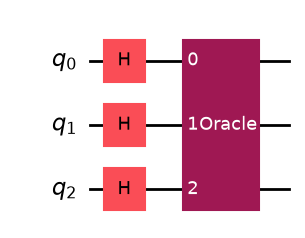

<IPython.core.display.Latex object>

In [8]:
expression = '(x2 & ~x1 & ~x0) | (x2 & ~x1 & x0)' # states 100 and 101
expression = '(x2 | x0)' # 
qiskit_expr = get_qiskit_expression(expression, 3)

oracle_gate = PhaseOracleGate(qiskit_expr,label='Oracle')

# Now just add it to your main circuit
n = 3 # Don't include ancilla
circuit = QuantumCircuit(n)
for qubit in range(n):
    circuit.h(qubit)
circuit.append(oracle_gate, range(n))
display(circuit.draw('mpl'))
psi = Statevector(circuit)
display(psi.draw('latex'))

## Transpiled oracle circuit  *(Book §12.3, Figure 12.4)*

Schematically the phase oracle is a single gate, but under the hood it is many basis gates. Transpiling
to `{u3, cx}` reveals them, and `estimateCircuitGates` reports the counts. The gate cost of a
`PhaseOracleGate` grows rapidly with the number of qubits and the complexity of the Boolean
expression — a point we quantify later with concrete numbers.

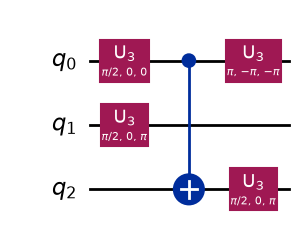

--- Circuit Analysis ---
Qubits: 3
Single-qubit gates: 4
CX/ECR gates: 1
Total gates: 5
Depth: 3
{'num_qubits': 3, 'single_gate_count': 4, 'cx_gates': 1, 'total_gates': 5, 'depth': 3, 'transpiled_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000246FAFE2E10>}


In [9]:
transpiled_circuit = transpile(circuit, basis_gates=['u3', 'cx'])
display(transpiled_circuit.draw('mpl'))
dict = estimateCircuitGates (transpiled_circuit)
print(dict)

## Truss feasibility as a phase oracle  *(Book §12.4, Example 12.5)*

Consider a truss with 7 members; each design is a bitstring $x_6\cdots x_0$ ($x_i=1$ if member $i$ is
present). For the structure to be acceptable, every loaded node must connect to at least one member,
giving constraints like $(x_0|x_1|x_2)\,\&\,(x_0|x_3|x_4)$. Feeding this expression to the phase
oracle flips the phase of exactly the **feasible** designs — i.e. it marks them, which is precisely
what Grover needs.

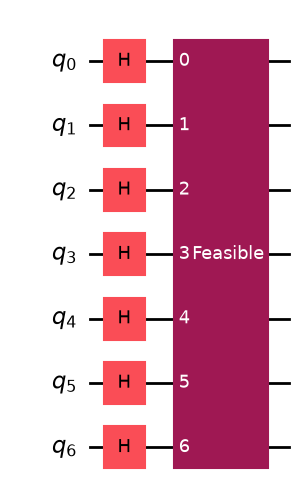

<IPython.core.display.Latex object>

In [10]:
n_members = 7
feasible_expr = "(x0 | x1 | x2) & (x0 | x3 | x4)"
# Ensure string variables are in the correct order for the oracle
qiskit_expr = get_qiskit_expression(feasible_expr, n_members)

oracle_gate = PhaseOracleGate(qiskit_expr,label="Feasible")
circuit = QuantumCircuit(n_members)
for qubit in range(n_members):
    circuit.h(qubit)
circuit.append(oracle_gate,range(n_members))
display(circuit.draw('mpl'))
psi = Statevector(circuit)
display(psi.draw('latex'))


### Transpiled feasibility oracle  *(Book §12.4, Table 12.1)*

Transpiling the 7-qubit truss oracle reports 73 single-qubit gates, 60 CX gates, and depth 108 —
compared with 6 CX gates for the 3-qubit oracle. This steep growth in CX count is the practical
bottleneck flagged in the remark above.

In [11]:
transpiled_circuit = transpile(circuit, basis_gates=['u3', 'cx'])
dict = estimateCircuitGates (transpiled_circuit)
print(dict)

--- Circuit Analysis ---
Qubits: 7
Single-qubit gates: 73
CX/ECR gates: 60
Total gates: 133
Depth: 108
{'num_qubits': 7, 'single_gate_count': 73, 'cx_gates': 60, 'total_gates': 133, 'depth': 108, 'transpiled_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000246FAF83F50>}


## The classical baseline: brute-force search  *(Book §12.4, Example 12.6)*

Now imagine a long Boolean expression with exactly **one** feasible design $s$. Classically we must
generate and test all $2^n$ bitstrings — an $O(2^n)$ search. Here `get_feasible_expression` returns
such an expression in 7 variables; the loop evaluates all $2^7=128$ strings and finds the single
solution $s = 1101101$. Grover will find the same $s$ in $O(2^{n/2})$ steps.

In [12]:
from Chapter12_GroverAlgorithm_functions import get_feasible_expression

n_members = 7
# generate a Boolean expression with one feasible solution
feasible_expr = get_feasible_expression() 
count = 0
for i in range(2**n_members):
    x0, x1, x2, x3, x4, x5, x6 = [int(b) for b in format(i, '07b')]
    if eval(feasible_expr):
        count += 1
        members = [j for j, b in enumerate([x0,x1,x2,x3,x4,x5,x6]) if b]
        bitstring = format(i,'07b')[::-1]  # reverse to match Qiskit ket order
        print(f"Solution: x6..x0 = {bitstring} -> active members {members}")

print(f"Total solutions: {count}")

Solution: x6..x0 = 1101101 -> active members [0, 2, 3, 5, 6]
Total solutions: 1


## Grover's algorithm  *(Book §12.7, Listing 12.1)*

The Grover operator = phase oracle $U$ (flip the phase of $|s\rangle$) followed by the reflection
$R_\psi = 2|\psi\rangle\langle\psi| - I$ about the uniform superposition; together they rotate the
state by $2\theta$ per iteration toward $|s\rangle$, where $\sin\theta = 1/\sqrt N$. The optimal
count is $K \approx \tfrac{\pi}{4}\sqrt N$ (here $K=8$). We build the circuit with `grover_operator`,
apply it $K$ times, measure, and recover $s=1101101$ with very high probability — a quadratic speedup
over the 128 classical evaluations.

Optimal number of Grover iterations: 8
{'1101101': 995, '1100010': 1, '0100001': 1, '1001001': 1, '1110111': 2}


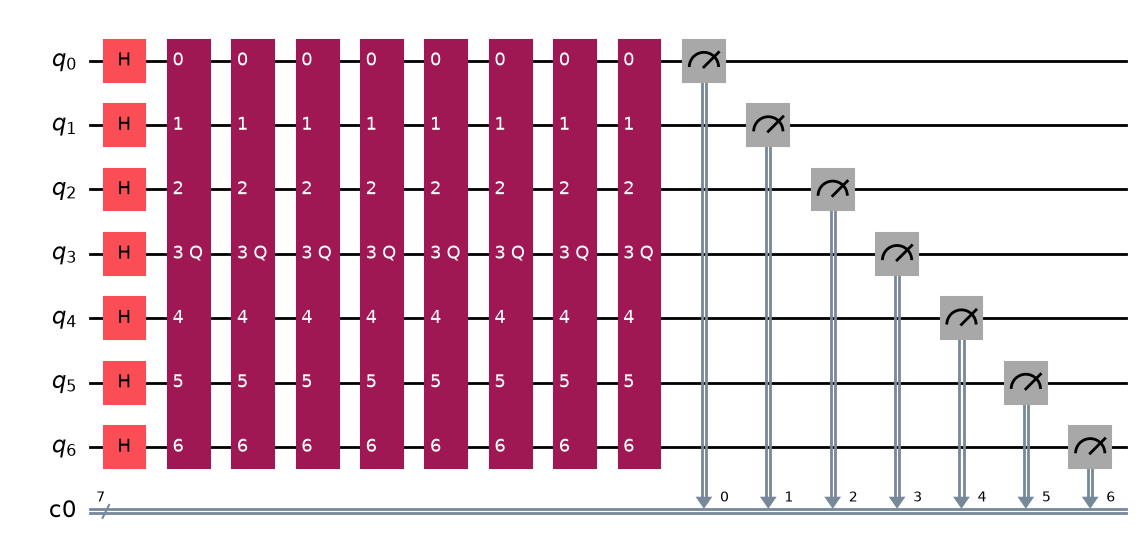

In [13]:
qiskit_expr = get_qiskit_expression(feasible_expr, n_members)

oracle = PhaseOracleGate(qiskit_expr,label="Feasible")
grover_op = grover_operator(oracle)

n_members  = 7
N = 2**n_members
K = math.floor(math.pi / (4 * math.asin(math.sqrt(1 / N))))
print("Optimal number of Grover iterations:", K)

qc = QuantumCircuit(grover_op.num_qubits)
qc.h(range(n_members))  # only superpose the search qubits, not ancillas
qc.compose(grover_op.power(K), inplace=True)

cr = ClassicalRegister(n_members)
qc.add_register(cr)
for i in range(n_members):
    qc.measure(i, cr[i])
counts = simulate_measurements(qc, shots=1000)
print(counts)
display(qc.draw('mpl'))

## Grover circuit analysis  *(Book §12.7)*

Having run Grover, we now inspect the resources it consumes — circuit width, depth, and gate counts —
to understand what it would take to run on real hardware.

### High-level width and depth  *(Book §12.7)*

`qc.width()` counts all qubits including ancillas, and `qc.depth()` reports depth at the level of the
high-level `grover_operator` blocks (before decomposition into basis gates).

In [14]:
print("width:", qc.width()) # includes ancillas
print("depth:", qc.depth()) # high level functions only

width: 14
depth: 10


### Transpiled gate counts  *(Book §12.7, Table 12.1)*

`estimateCircuitGates` decomposes to basis gates and counts them. Going from the 3-qubit oracle to
the 7-qubit truss oracle, the CX count jumps from 6 to 60 — a $6\times$ increase for a $2\times$
increase in qubits. Since CX gates dominate NISQ noise (Chapter 11), and this cost is incurred at
*every* Grover iteration ($\times K$), the truss circuit sits at the edge of what current hardware
can execute reliably — a concrete reason Grover awaits fault-tolerant hardware at engineering scale.

In [15]:
info = estimateCircuitGates(qc)
print("Grover Circuit:", info)

--- Circuit Analysis ---
Qubits: 7
Single-qubit gates: 2417
CX/ECR gates: 2180
Total gates: 4597
Depth: 2984
Grover Circuit: {'num_qubits': 7, 'single_gate_count': 2417, 'cx_gates': 2180, 'total_gates': 4597, 'depth': 2984, 'transpiled_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000246F969E510>}


### Over- and under-rotation: success probability vs. $K$  *(Book §12.7, Example 12.8, Listing 12.2)*

Equation (12.4) gives the exact success probability after $K$ iterations,
$$P(K) = \sin^2\!\big((2K+1)\theta\big), \qquad \theta = \sin^{-1}(1/\sqrt N).$$
This is *periodic* in $K$: rotating past $|s\rangle$ makes the probability fall again. For the truss
problem ($N=128$, $\theta\approx0.089$, $K_{\text{opt}}=8$) we sweep $K$ from 0 to 30 and record the
exact statevector probability. The curve peaks at $K=8$, dips to a near-zero trough around $K=17$
(half the period $\pi/(2\theta)\approx17.7$), and rises to a second peak near $K=26$ — so choosing
$K$ too large is just as harmful as too small.

In [ ]:
from Chapter12_GroverAlgorithm_functions import (
    bitstring_to_expression, get_qiskit_expression
)
# ── Setup ──────────────────────────────────────────────────────────────────────
n_members = 7
N         = 2**n_members
TARGET    = '1101101'        # the single feasible truss design
 
feasible_expr = bitstring_to_expression(TARGET)
qiskit_expr   = get_qiskit_expression(feasible_expr, n_members)
 
oracle    = PhaseOracleGate(qiskit_expr, label="Feasible")
grover_op = grover_operator(oracle)
 
theta = math.asin(1 / math.sqrt(N))
K_opt = math.floor(math.pi / (4 * theta) - 0.5)
print(f"theta  = {theta:.6f} rad")
print(f"K_opt  = {K_opt}")
print(f"Period = pi/(2*theta) ≈ {math.pi / (2 * theta):.1f} iterations")
 
# ── Probability sweep K = 0 … 30 ──────────────────────────────────────────────
K_range = range(31)
P_theory = [math.sin((2*K + 1) * theta)**2 for K in K_range]
 
P_exact = []
for K in K_range:
    qc = QuantumCircuit(grover_op.num_qubits)
    qc.h(range(n_members))
    if K > 0:
        qc.compose(grover_op.power(K), inplace=True)
    sv    = Statevector(qc)
    probs = sv.probabilities_dict(qargs=list(range(n_members)))
    P_exact.append(probs.get(TARGET, 0.0))
 
# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
 
ax.plot(K_range, P_theory, 'b-o', markersize=4, label=r'$\sin^2\!((2K+1)\,\theta)$')
ax.axvline(K_opt, color='red',  linestyle='--', linewidth=1.5,
           label=f'$K_{{\\rm opt}} = {K_opt}$')
ax.axvline(26,    color='green', linestyle='--', linewidth=1.5,
           label=f'Second peak $K = 26$')
 
ax.set_xlabel('Number of Grover iterations $K$', fontsize=12)
ax.set_ylabel('Success probability $P(K)$',       fontsize=12)
ax.set_title('Over-rotation: truss feasibility problem ($N=128$, $M=1$)', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_xticks(range(0, 31, 2))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('grover_overrotation.png', dpi=150)
plt.show()
print("Saved: grover_overrotation.png")
 
# ── Print key values ───────────────────────────────────────────────────────────
print(f"\n{'K':>3}  {'P(K)':>8}")
print(f"{'--':>3}  {'----':>8}")
for K in K_range:
    marker = " <-- K_opt" if K == K_opt else (" <-- 2nd peak" if K == 26 else "")
    print(f"{K:3d}  {P_theory[K]:8.4f}{marker}")

theta  = 0.088504 rad
K_opt  = 8
Period = pi/(2*theta) ≈ 17.7 iterations


## Microstructure void detection  *(Book §12.8)*

We now turn to a different engineering problem: a square plate modeled as a $2^m\times2^m$ grid of
material cells, solid except for a few **voids** (manufacturing defects). The task is to locate the
voids. The naive analogy with the truss — one qubit per cell — would need $N=2^{2m}$ qubits (256 for
a $16\times16$ grid). The key insight is that grid cells have geometric structure, so we can search
over cell *addresses* instead.

### Generating a microstructure  *(Book §12.8, Example 12.9)*

We construct a $16\times16$ microstructure with a small fraction of random voids using
`MicrostructureGenerator`. The void locations are hidden from the search; they are shown only for
illustration.

Target inclusion fraction: 0.010
Actual inclusion fraction: 0.012


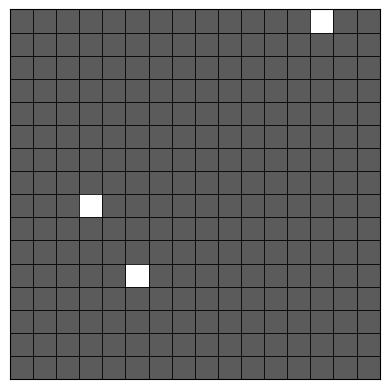

In [ ]:
from Chapter03_EngineeringProblems_functions import MicrostructureGenerator

microstructure = MicrostructureGenerator(nx=16, ny=16, inclusion_fraction=0.01, micro_type='random_elements')
microstructure.plot()

### Coordinate encoding: address, not cells  *(Book §12.8, Table 12.2)*

Instead of one qubit per cell, we encode each void by its row-column coordinates on two $m$-qubit
registers, needing only $2m=\log_2 N$ qubits (8 vs. 256 for the $16\times16$ grid). `get_void_expression`
builds the oracle as a disjunction of one conjunction per void address. The savings grow exponentially
with grid size — this coordinate encoding is available for any regular grid, unlike the unstructured
truss.

In [ ]:
from Chapter12_GroverAlgorithm_functions import get_void_expression


# ── Cell 2: Coordinate encoding ───────────────────────────────────────────────
expression, n_qubits, void_coords, all_vars = get_void_expression(grid=microstructure.data)
 
grid_array = np.array(microstructure.data)
rows, cols = grid_array.shape
m = int(np.log2(rows))          # register size: rows = cols = 2^m
N = rows * cols                 # search space: N coordinate pairs
M = len(void_coords)            # marked states: one per void
 
print(f"Grid        : {rows} x {cols}  (m={m})")
print(f"Search space: N = {N} coordinate pairs")
print(f"Qubits      : 2m = {n_qubits}  (vs {N} for flat encoding)")
print(f"Voids (M={M}): {void_coords}")
print()

Grid        : 16 x 16  (m=4)
Search space: N = 256 coordinate pairs
Qubits      : 2m = 8  (vs 256 for flat encoding)
Voids (M=3): [(4, 5), (7, 3), (15, 13)]



## Grover on the microstructure  *(Book §12.8, Listing 12.3)*

With $M$ voids in a search space of size $N$, the multi-solution optimal count uses
$\theta = \sin^{-1}\!\sqrt{M/N}$, giving $K \approx \tfrac{\pi}{4\theta} - \tfrac12$ (Eq. 12.5). We
assemble and run the Grover circuit exactly as before, then `decode_void_measurement` maps the
measured bitstrings back to $(\text{row},\text{col})$ coordinates. All $M$ void locations are
recovered simultaneously with roughly equal probability; the remaining shots are low-probability
noise. When $M$ is unknown, a geometric-increase strategy ($K=1,2,4,8,\dots$) preserves the
$O(\sqrt N)$ cost.

In [ ]:
from qiskit.circuit.library import PhaseOracleGate
from Chapter12_GroverAlgorithm_functions import decode_void_measurement
 

qiskit_expr = get_qiskit_expression(expression, n_qubits, prefix_vars=all_vars)

 
oracle    = PhaseOracleGate(qiskit_expr, label="Void")
grover_op = grover_operator(oracle)
 
# Optimal K -- Eq. (12.4) for M solutions in search space of size N
theta = math.asin(math.sqrt(M / N))
K     = max(1, math.floor(math.pi / (4 * theta) - 0.5))
print(f"Optimal Grover iterations K = {K}")
 
qc = QuantumCircuit(grover_op.num_qubits)
qc.h(range(n_qubits))
qc.compose(grover_op.power(K), inplace=True)
cr = ClassicalRegister(n_qubits)
qc.add_register(cr)
for i in range(n_qubits):
    qc.measure(i, cr[i])
 
counts = simulate_measurements(qc, shots=1000)
 
# Decode bitstrings back to (row, col) coordinates
print("\nMeasurement results (bitstring -> (row, col) : count):")
for bitstring, count in sorted(counts.items(), key=lambda x: -x[1]):
    row, col = decode_void_measurement(bitstring, m)
    marker = " <-- void" if (row, col) in void_coords else ""
    print(f"  {bitstring} -> ({row},{col}) : {count}{marker}")
 

Optimal Grover iterations K = 6

Measurement results (bitstring -> (row, col) : count):
  01010100 -> (4,5) : 359 <-- void
  00110111 -> (7,3) : 314 <-- void
  11011111 -> (15,13) : 296 <-- void
  01010101 -> (5,5) : 2
  01000111 -> (7,4) : 1
  11100100 -> (4,14) : 1
  01001100 -> (12,4) : 1
  00001110 -> (14,0) : 1
  11010000 -> (0,13) : 1
  11101100 -> (12,14) : 1
  10010111 -> (7,9) : 1
  01110111 -> (7,7) : 1
  00111100 -> (12,3) : 1
  01001011 -> (11,4) : 1
  11100001 -> (1,14) : 1
  11011011 -> (11,13) : 1
  11100011 -> (3,14) : 1
  01000001 -> (1,4) : 1
  10010011 -> (3,9) : 1
  01101011 -> (11,6) : 1
  10110001 -> (1,11) : 1
  10000011 -> (3,8) : 1
  01010000 -> (0,5) : 1
  01011110 -> (14,5) : 1
  01111111 -> (15,7) : 1
  01110100 -> (4,7) : 1
  11010001 -> (1,13) : 1
  11101011 -> (11,14) : 1
  11110100 -> (4,15) : 1
  00000011 -> (3,0) : 1
  00010101 -> (5,1) : 1
  01101110 -> (14,6) : 1
  00101001 -> (9,2) : 1
